In [1]:
import pickle, gzip
import pandas as pd
import numpy as np
import copy
from pathlib import Path

In [2]:
def save_y_and_params(y_dict, params, out_path, compress=True):
    """
    y_dict: e.g. {"train": y_train, "val": y_val, "test": y_test}
    params: dict of hyperparameters/config
    out_path: path to .pkl or .pkl.gz
    """
    payload = {"y": y_dict, "params": params}
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    opener = gzip.open if compress else open
    with opener(out_path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_y_and_params(path, compressed=True):
    opener = gzip.open if compressed else open
    with opener(path, "rb") as f:
        payload = pickle.load(f)
    return payload["y"], payload["params"]

In [3]:
(y_loaded, params_loaded) = load_y_and_params("../results/data/mix/r100_y_and_params5.pkl", compressed=False)

In [4]:
y_pred = y_loaded['pred']
y_test = y_loaded['test']
dt = params_loaded['dt']
ls = params_loaded['ls']
r2 = params_loaded['r2']

In [5]:
df_list = []
for i, (y_p, y_t, d, l, r2_) in enumerate(zip(y_pred, y_test, dt,ls, r2)):

    df = pd.DataFrame(columns=['pred', 'test', 'dt', 'age', 'error'])
    y_p = y_p.flatten()
    y_t = y_t.flatten()
    d = d.flatten()
    lb = l[:,2]
    error = np.abs((y_p - y_t)/y_t)

    df_ = pd.DataFrame({'pred':y_p,
                       'test':y_t,
                       'dt':d,
                       'age':lb, 
                       'error':error})

    df_list.append(copy.deepcopy(df_))

In [6]:
df = pd.concat(df_list)

In [7]:
df

,pred,test,dt,age,error
0,19.904186,17.299999,56.0,5.08225,0.150531
1,23.778099,21.100000,63.0,5.909582,0.126924
2,22.490452,23.200001,56.0,6.016906,0.030584
3,24.535448,26.100000,70.0,5.427219,0.059945
4,25.626778,24.799999,28.0,6.067264,0.033338
...,...,...,...,...,...
5581,6.093748,6.800000,148.0,3.386037,0.103861
5582,8.050690,5.900000,65.0,4.463552,0.364524
5583,4.443034,6.900000,138.0,4.445106,0.356082
5584,7.037911,10.100000,51.0,4.711281,0.303177


In [8]:
df['dt']  = pd.to_numeric(df['dt'],  errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# 1) dt bins: 0–30, 31–60, …, 331–360, >360
dt_edges   = [-np.inf] + list(range(30, 361, 30)) + [np.inf]   # [-inf,30,60,...,360,inf]
dt_labels  = (["≤30"] 
              + [f"{i-29}–{i}" for i in range(60, 361, 30)] 
              + [">360"])
df['dt_bin'] = pd.cut(df['dt'], bins=dt_edges, labels=dt_labels,
                      right=True, include_lowest=True)

# 2) age cohorts: <6, 6–<12, 12–<18, 18–<24, 24–49, ≥50
age_edges  = [-np.inf, 6, 12, 18, 24, 50, np.inf]
age_labels = ["Infant_toddler", "School Age", "Teenager", "Young Adult", "Mature Adult", "Older Adult"]
df['age_cohort'] = pd.cut(df['age'], bins=age_edges, labels=age_labels, right=False)

In [9]:
df.age_cohort.unique()

['Infant_toddler', 'School Age', 'Teenager', 'Mature Adult', 'Young Adult', 'Older Adult']
Categories (6, object): ['Infant_toddler' < 'School Age' < 'Teenager' < 'Young Adult' < 'Mature Adult' < 'Older Adult']

In [10]:
g = (df
     .dropna(subset=['error', 'dt_bin', 'age_cohort'])
     .groupby(['age_cohort', 'dt_bin'])['error']
     .agg(n='size', mean='mean', std='std')
     .reset_index())

# (Optional) nicer rounding
g['mean'] = g['mean'].round(4)
g['std']  = g['std'].round(4)

print(g.head())

       age_cohort   dt_bin      n    mean     std
0  Infant_toddler      ≤30  33000  0.3384  0.5954
1  Infant_toddler    31–60  45885  0.1592  0.3282
2  Infant_toddler    61–90  22701  0.1556  0.3025
3  Infant_toddler   91–120  10027  0.1945  0.4979
4  Infant_toddler  121–150   3359  0.2427  0.2689


/lsf_tmp/269779784.tmpdir/ipykernel_2712109/4035713558.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['age_cohort', 'dt_bin'])['error']


In [11]:
mean_table = g.pivot(index='age_cohort', columns='dt_bin', values='mean')
std_table  = g.pivot(index='age_cohort', columns='dt_bin',  values='std')

# Optional rounding
mean_table = mean_table.round(4)
std_table  = std_table.round(4)


In [12]:
mean_table

dt_bin,≤30,31–60,61–90,91–120,121–150,151–180,181–210,211–240,241–270,271–300,301–330,331–360,>360
age_cohort,,,,,,,,,,,,,
Infant_toddler,0.3384,0.1592,0.1556,0.1945,0.2427,0.2700,0.2635,0.3321,0.2986,0.3468,0.3631,0.4152,0.4021
School Age,0.4615,0.2575,0.2523,0.2877,0.4573,0.3873,0.4235,0.4466,0.3813,0.5094,0.4314,0.5934,0.5217
Teenager,0.6266,0.3712,0.3693,0.3906,0.4866,0.3805,0.5801,0.8009,0.8802,1.0231,0.7191,2.1990,0.6863
Young Adult,0.6520,0.4760,0.4834,0.4574,0.6920,0.5329,0.5493,0.4487,0.7214,0.5149,0.4726,0.2125,0.7851
Mature Adult,0.5537,0.6325,0.6159,0.6309,0.8412,0.7401,0.4035,0.6044,0.6599,0.2251,0.4088,0.2742,0.7025
Older Adult,0.3749,0.7299,0.3331,0.2269,1.3811,0.3200,NaN,0.4260,NaN,NaN,NaN,NaN,0.7819


In [13]:
import matplotlib.pyplot as plt
from pandas.api.types import is_categorical_dtype

def plot_boxplots_by_cohort_dtbin(df, err_col='error', cohort_col='age_cohort', bin_col='dt_bin',
                                  save_dir=None, hline=0.25):
    """
    For each age_cohort, plot a boxplot of `err_col` across dt_bin categories.
    If save_dir is provided, saves each figure as PNG and returns list of paths.
    Draws a horizontal line at `hline` if not None.
    """
    data = df.dropna(subset=[err_col, cohort_col, bin_col]).copy()

    # preserve categorical order if present
    if is_categorical_dtype(data[bin_col]):
        dt_order = list(data[bin_col].cat.categories)
    else:
        dt_order = sorted(data[bin_col].unique(), key=lambda x: str(x))

    if is_categorical_dtype(data[cohort_col]):
        cohort_order = list(data[cohort_col].cat.categories)
    else:
        cohort_order = sorted(data[cohort_col].unique(), key=lambda x: str(x))

    saved = []
    for cohort in cohort_order:
        subset = data[data[cohort_col] == cohort]
        vals, labels = [], []
        for b in dt_order:
            arr = subset.loc[subset[bin_col] == b, err_col].to_numpy()
            if arr.size > 0:
                vals.append(arr)
                labels.append(str(b))
        if not vals:
            continue

        fig, ax = plt.subplots(figsize=(max(6, 1.1 * len(labels)), 4))
        ax.boxplot(vals, patch_artist=False, showfliers=False)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_title(f'Error by dt_bin — Age Cohort: {cohort}')
        ax.set_xlabel('dt_bin')
        ax.set_ylabel(err_col)
        ax.grid(True, axis='y', alpha=0.3)

        # horizontal reference line
        if hline is not None:
            ax.axhline(hline, linestyle='--', linewidth=1)
            # optional label:
            # ax.text(0.99, hline, f'{hline}', va='bottom', ha='right', transform=ax.get_yaxis_transform())

        fig.tight_layout()

        if save_dir:
            import os
            os.makedirs(save_dir, exist_ok=True)
            path = f"{save_dir}/box_{str(cohort).replace(' ', '_')}.png"
            fig.savefig(path, dpi=150)
            saved.append(path)

        plt.show()

    return saved


/lsf_tmp/269779784.tmpdir/ipykernel_2712109/985002051.py:14: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(data[bin_col]):
/lsf_tmp/269779784.tmpdir/ipykernel_2712109/985002051.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(data[cohort_col]):


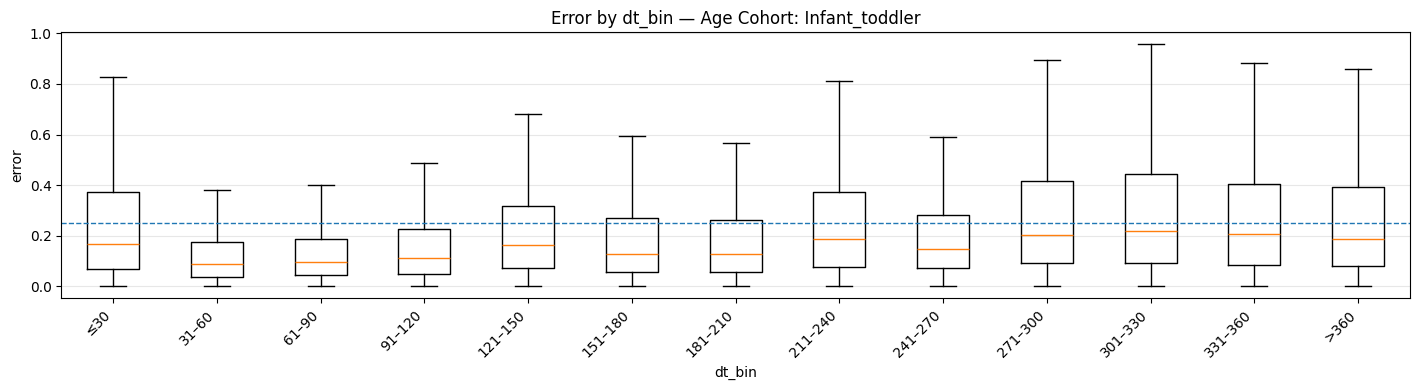

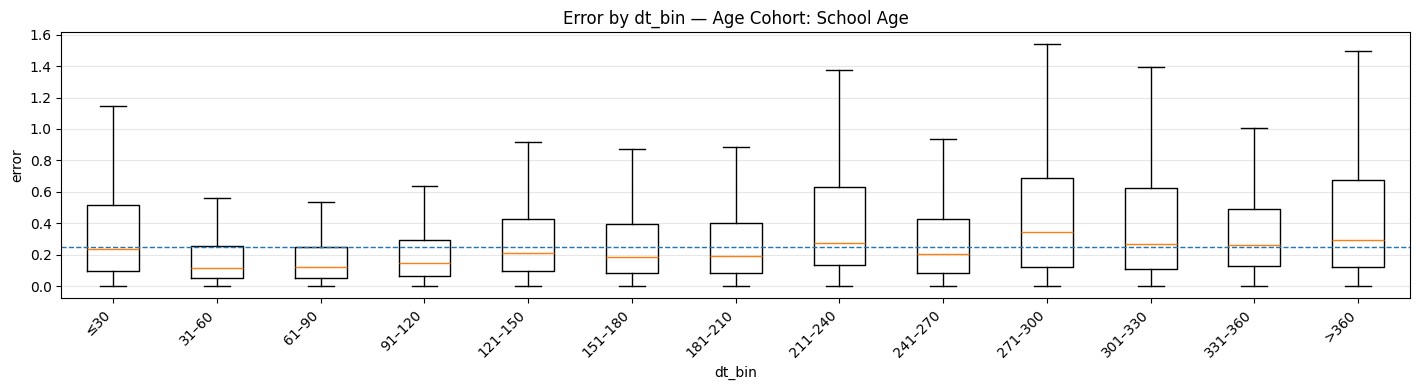

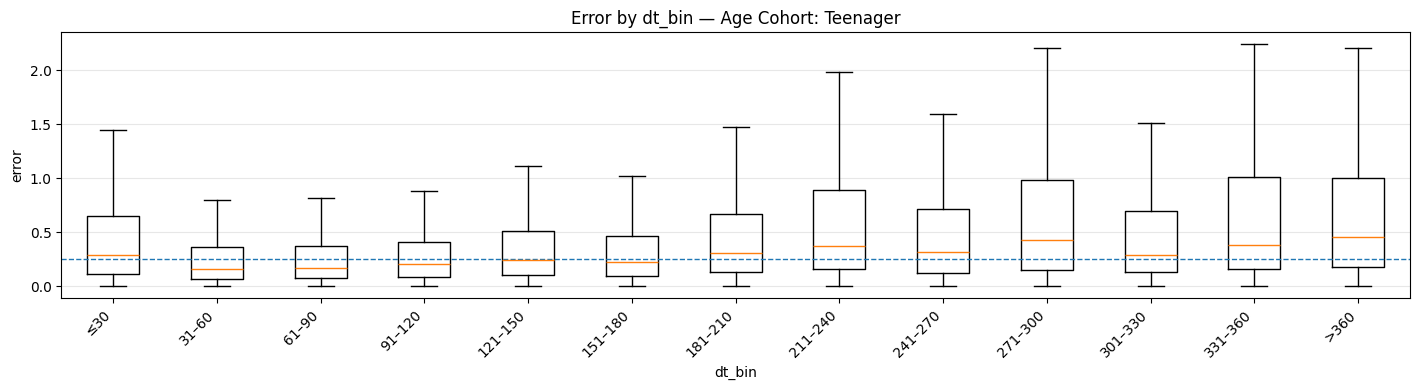

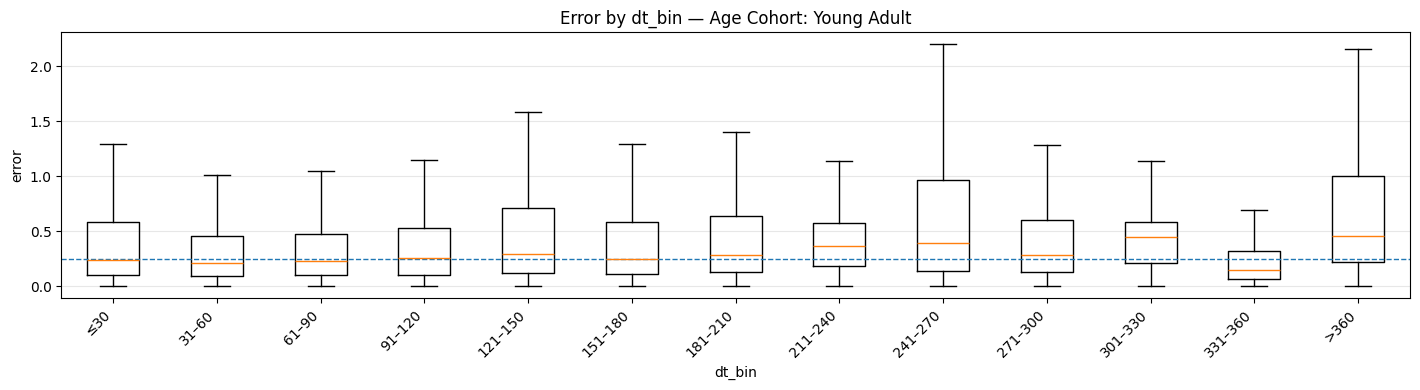

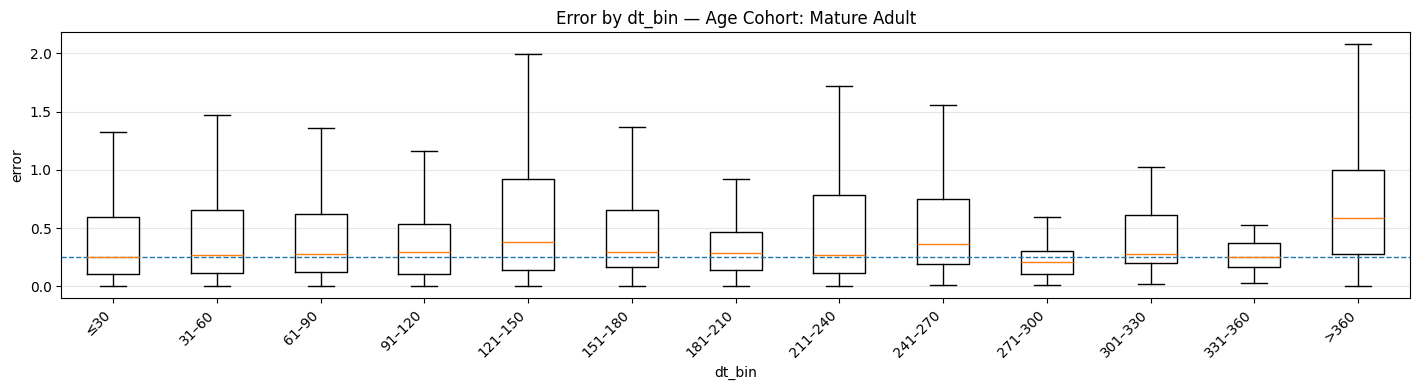

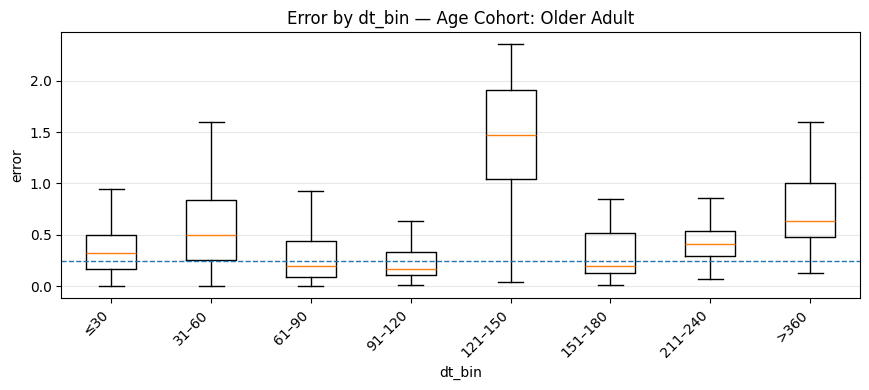

['../results/figures/mix/error_mix/box_Infant_toddler.png',
 '../results/figures/mix/error_mix/box_School_Age.png',
 '../results/figures/mix/error_mix/box_Teenager.png',
 '../results/figures/mix/error_mix/box_Young_Adult.png',
 '../results/figures/mix/error_mix/box_Mature_Adult.png',
 '../results/figures/mix/error_mix/box_Older_Adult.png']

In [14]:
plot_boxplots_by_cohort_dtbin(df, err_col='error', cohort_col='age_cohort', bin_col='dt_bin', save_dir="../results/figures/mix/error_mix")

In [15]:
import math

def plot_boxplots_subplots(df, err_col='error', cohort_col='age_cohort', bin_col='dt_bin',
                           ncols=3, hline=0.25, showfliers=False, sharey=False):
    """
    Create a grid of subplots: each subplot shows a boxplot of `err_col`
    across `bin_col` for a single `cohort_col` level.

    Parameters
    ----------
    df : DataFrame with columns [err_col, cohort_col, bin_col]
    ncols : number of subplot columns
    hline : draw horizontal reference line (None to disable)
    showfliers : pass to boxplot(showfliers=...)
    sharey : share y-axis across subplots for easier comparison
    """
    data = df.dropna(subset=[err_col, cohort_col, bin_col]).copy()

    # Determine ordered categories
    if is_categorical_dtype(data[bin_col]):
        dt_order = list(data[bin_col].cat.categories)
    else:
        dt_order = sorted(data[bin_col].unique(), key=lambda x: str(x))

    if is_categorical_dtype(data[cohort_col]):
        cohort_order = list(data[cohort_col].cat.categories)
    else:
        cohort_order = sorted(data[cohort_col].unique(), key=lambda x: str(x))

    n = len(cohort_order)
    ncols = max(1, int(ncols))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(max(9, 3.2*ncols), max(4, 3.2*nrows)),
                             squeeze=False, sharey=sharey)

    # Optional: consistent y-limits (uses all data)
    if sharey:
        y_all = data[err_col].to_numpy()
        y_min = np.nanpercentile(y_all, 1)
        y_max = np.nanpercentile(y_all, 99)
        # widen a bit
        pad = 0.05 * (y_max - y_min + 1e-9)
        y_limits = (y_min - pad, y_max + pad)
    else:
        y_limits = None

    idx = 0
    for r in range(nrows):
        for c in range(ncols):
            ax = axes[r, c]
            if idx >= n:
                ax.axis('off')
                continue

            cohort = cohort_order[idx]
            sub = data[data[cohort_col] == cohort]

            # Collect arrays per dt_bin (skip empty)
            vals, labels = [], []
            for b in dt_order:
                arr = sub.loc[sub[bin_col] == b, err_col].to_numpy()
                if arr.size > 0:
                    vals.append(arr)
                    labels.append(str(b))

            if vals:
                ax.boxplot(vals, showfliers=showfliers, patch_artist=False)
                ax.set_xticks(range(1, len(labels) + 1))
                ax.set_xticklabels(labels, rotation=45, ha='right')

            ax.set_title(f'{cohort}')
            if y_limits is not None:
                ax.set_ylim(*y_limits)
            if hline is not None:
                ax.axhline(hline, linestyle='--', linewidth=1)

            # Axis labels on outer edges only
            if r == nrows - 1:
                ax.set_xlabel('Delta T')
            if c == 0:
                ax.set_ylabel(err_col)

            ax.grid(True, axis='y', alpha=0.3)
            idx += 1

    plt.tight_layout()
    plt.show()
    return fig, axes


/lsf_tmp/269779784.tmpdir/ipykernel_2712109/13226425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f['age_cohort'] = df_f['age_cohort'].cat.remove_unused_categories()
/lsf_tmp/269779784.tmpdir/ipykernel_2712109/121831641.py:20: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(data[bin_col]):
/lsf_tmp/269779784.tmpdir/ipykernel_2712109/121831641.py:25: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(data[cohort_col]):


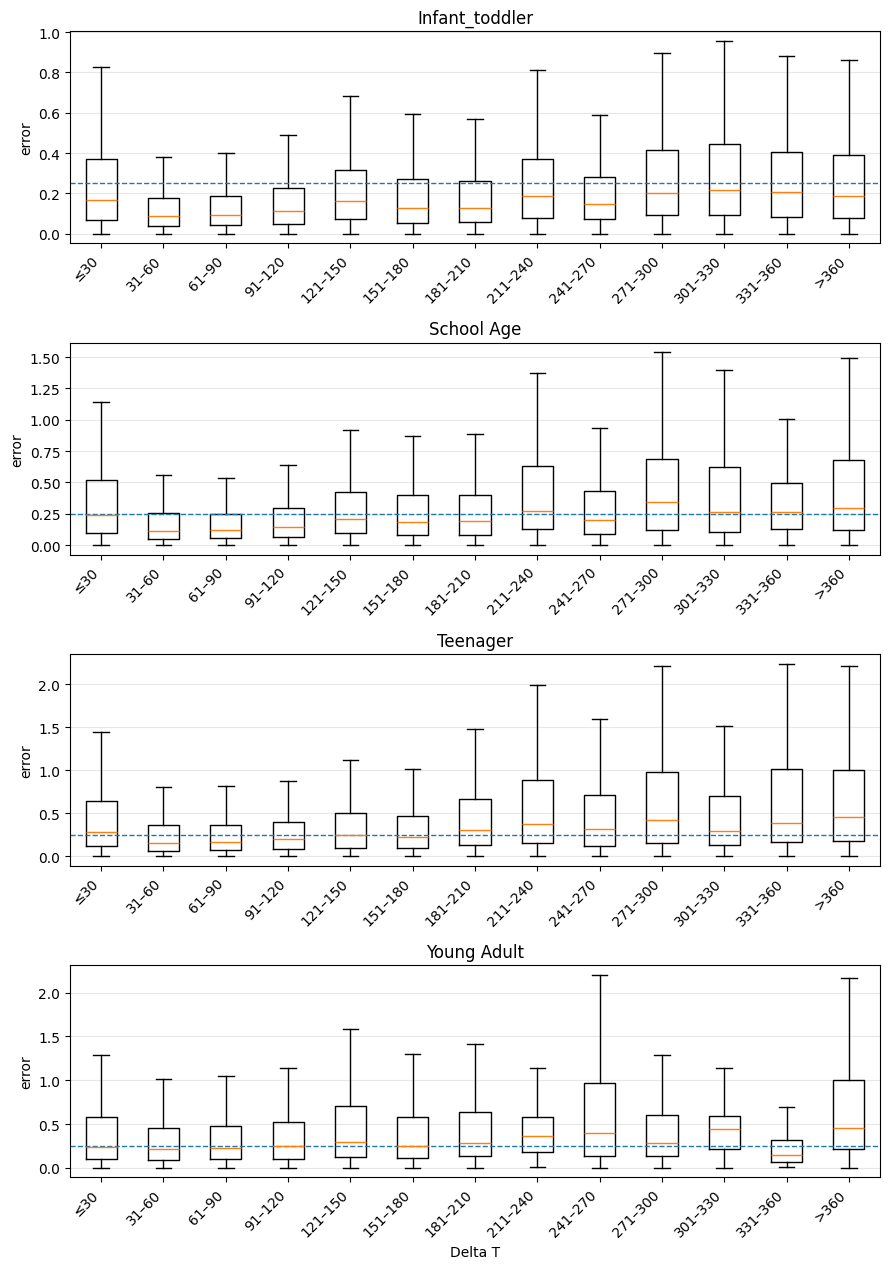

(<Figure size 900x1280 with 4 Axes>,
 array([[<Axes: title={'center': 'Infant_toddler'}, ylabel='error'>],
        [<Axes: title={'center': 'School Age'}, ylabel='error'>],
        [<Axes: title={'center': 'Teenager'}, ylabel='error'>],
        [<Axes: title={'center': 'Young Adult'}, xlabel='Delta T', ylabel='error'>]],
       dtype=object))

In [16]:
df_f = df[df['age_cohort'].isin(["Infant_toddler", "School Age", "Teenager", "Young Adult"])]
df_f['age_cohort'] = df_f['age_cohort'].cat.remove_unused_categories()
plot_boxplots_subplots(
    df_f, err_col='error', cohort_col='age_cohort', bin_col='dt_bin',
    ncols=1, hline=0.25, showfliers=False, sharey=False
)
